# Notebook principale modele SIR


### packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

## Parametres

In [4]:
# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérit

# paramètre de contagion
beta=0.6 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
R0=beta/gamma*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

- Nombre de personnes brutes infectées initialement par 1 malade:  R0 (S(t)=1)
- Nombre de personnes à t infectées par 1 malade:  R0 *P(de tomber sur un porteur jamais infecté) = R0 * S
NB: S est le pourcentage de porteur sain (nb entre 0 et 1 qui represente la probabilité de tomber surun porteur sain).


## Calcul Modele SIR simple

In [5]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
Rt = np.empty(n)

y = np.empty(3)
y[0] = S_init
y[1] = I_init
y[2] = R_init

params={"beta":beta,"gamma":gamma}
model=mathUtils.SIR(params)
deriv=model.deriv_SIR
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

## Graphes

In [6]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sir_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sir_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sir_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sir_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sir_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sir_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sir_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sir_Rt.pdf", bbox_inches=\'tight\')\nplt.show()\n'

## tout en 1

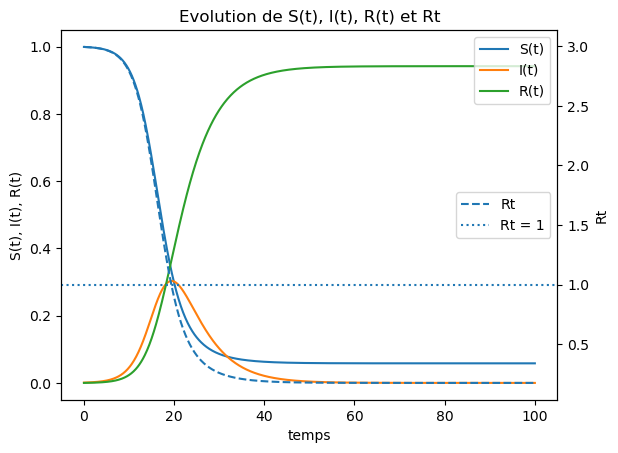

In [7]:
plt.figure()
plt.title("Evolution de S(t), I(t), R(t) et Rt")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("sir_SIR_Rt.pdf", bbox_inches='tight')
plt.show()

Quand R0=1, l'epidemie est en remission. Un porteur affecte moins d'une personne en moyenne.

On cherche :
$$
\frac{dI}{dt}=\beta SI-\gamma I = I(\beta S-\gamma) <0
$$
soit:
$$
 I(\frac{\beta}{\gamma} S-\frac{\gamma}{\gamma}) = I(R-1) <0
$$


Ainsi, une dérivée négative de I correspond bien  à $R_0<1$

### Rappel def du Rt

### 3. Nombre moyen total de personnes contaminées par un infecté

Le nombre moyen de personnes contaminées par un individu infecté s’obtient en multipliant le taux de contamination par la durée infectieuse moyenne :

$$
\text{nb moyen de contaminations}=
\text{tx de contamination}\times \text{durée infectieuse moy}
$$

Or, le tx de contamination par individu infecté vaut :

$$
\frac{\beta SI}{I}=\beta S
$$

et la durée infectieuse moyenne vaut :

$$
\frac{1}{\gamma}
$$

Ainsi,

$$
(\beta S)\times \frac{1}{\gamma}=\frac{\beta}{\gamma}S
$$

On obtient donc :

$$
R_t=\frac{\beta}{\gamma}S
$$

## Explication probabiliste sur la dynamique de contamination visible dans l'EDO de S

- Le coefficient beta représente le taux de transmission de base de la maladie pour I=100%.

- donc Avec I individus infectés on pondère ce taux par I

- Puis on multiplie par la probabilité de tomber sur un individu sain (on ne peut pas infecter ni quelqu'un d'infecté, ni quelqu'un qui a deja eu la maladie dans cette hypothèse), c'est a dire par la proportion d'individus susceptibles S.

Ainsi, le taux de nouvelles contaminations est donné par

$$
\beta I S.
$$

On obtient alors l'équation

$$
\frac{dS}{dt}=-\beta I S.
$$

On bonen idée ici serait d'ajouter donc également un coéfficient mu à R, permettant de réduire R, symbolisant le temps à partir du duquel on est plus immunisé.

### Comparaison du seuil de population immunisé ppur arreter l'epidemie en fonction du R0.

In [8]:

gamma = 0.2
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

# boucle sur beta : de 0.2 à 3.0 , donc de R0=1 à 15
betaTab = np.arange(0.2, 3.0 + 0.2, 0.2)

# vecteurs résultats
R0List = np.empty(betaTab.size)
RtFinal = np.empty(betaTab.size)
RFinal = np.empty(betaTab.size)
immunisesFinal = np.empty(betaTab.size)
epidemie_endigue_list = np.empty(betaTab.size)
epidemie_endigue=False

for k, beta in enumerate(betaTab):

    R0 = beta / gamma * S_init
    R0List[k] = R0
    S = np.empty(n)
    I = np.empty(n)
    R = np.empty(n)
    y = np.empty(3)
    y[0] = S_init
    y[1] = I_init
    y[2] = R_init

    params = {"beta": beta, "gamma": gamma}
    model = mathUtils.SIR(params)
    deriv = model.deriv_SIR
    euler = model.euler

    for i in range(n):
        S[i] = y[0]
        I[i] = y[1]
        R[i] = y[2]
        Rt= S[i]*R0
        if not epidemie_endigue and Rt<=1  :
            epidemie_endigue = True
            epidemie_endigue_list[k]=R[i]

        t = temps[i]
        y = euler(t, dt, y, deriv)

    immunisesFinal[k] = 100 * R[-1]

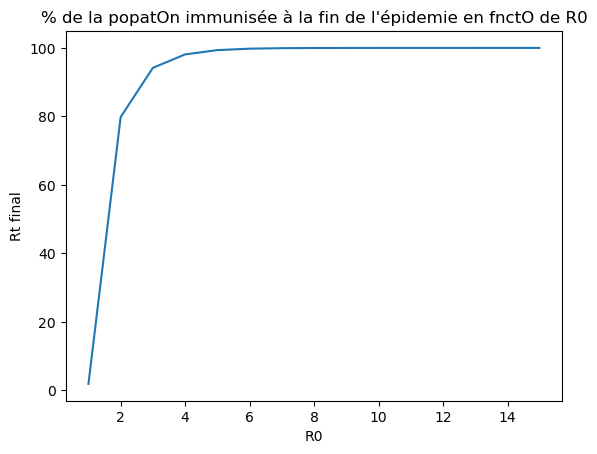

In [9]:
plt.figure()
plt.title("% de la popatOn immunisée à la fin de l'épidemie en fnctO de R0")
plt.plot(R0List, immunisesFinal)
plt.xlabel("R0")
plt.ylabel("Rt final")
plt.savefig("sir_Rtfinal_vs_R0.pdf", bbox_inches='tight')
plt.show()

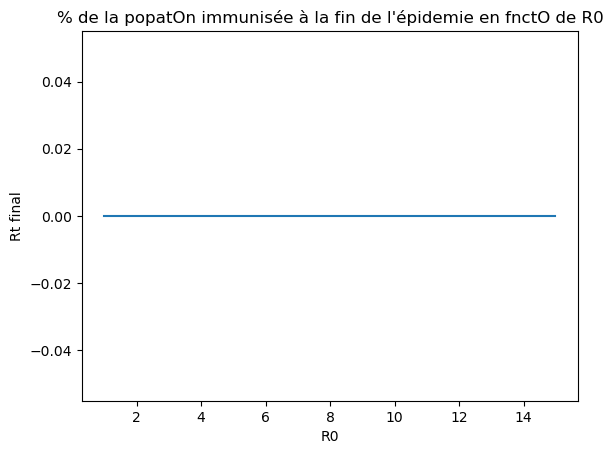

In [10]:
plt.figure()
plt.title("% de la popatOn immunisée à la fin de l'épidemie en fnctO de R0")
plt.plot(R0List, epidemie_endigue_list)
plt.xlabel("R0")
plt.ylabel("Rt final")
plt.savefig("sir_Rtfinal_vs_R0.pdf", bbox_inches='tight')
plt.show()

,Virus,R0
0,Ebola,1.95
1,Grippe saisonniere,1.27
2,COVID initial,2.79
3,COVID Delta,5.08
4,COVID Omicron,9.50
5,Variole,4.75
6,Rougeole,15.00


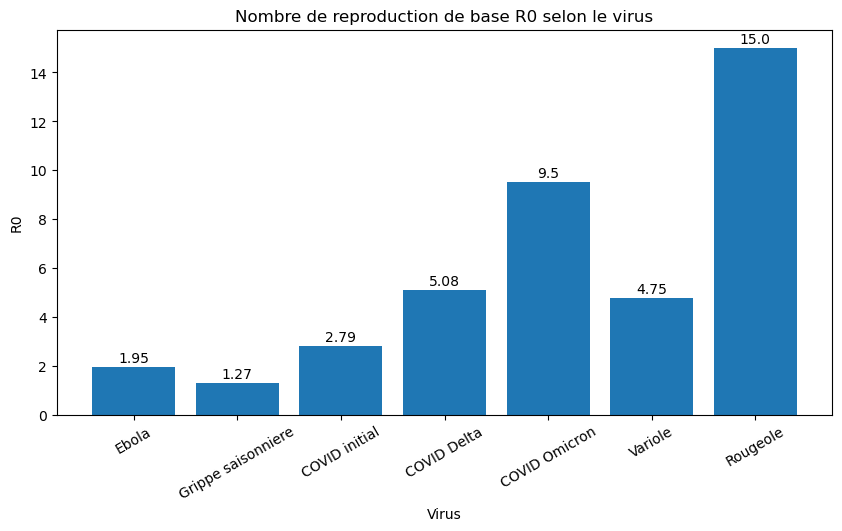

In [11]:

virus = [
    "Ebola",
    "Grippe saisonniere",
    "COVID initial",
    "COVID Delta",
    "COVID Omicron",
    "Variole",
    "Rougeole"
]

R0 = [
    1.95,   # Ebola
    1.27,   # grippe saisonniere
    2.79,   # COVID souche initiale
    5.08,   # Delta
    9.5,    # Omicron
    4.75,   # variole
    15.0    # rougeole
]

# DataFrame
df = pd.DataFrame({
    "Virus": virus,
    "R0": R0
})

display(df)

x = np.arange(len(virus))
plt.figure(figsize=(10, 5))
plt.bar(x, R0)
plt.xticks(x, virus, rotation=30)
plt.xlabel("Virus")
plt.ylabel("R0")
plt.title("Nombre de reproduction de base R0 selon le virus")

for i, v in enumerate(R0):
    plt.text(i, v + 0.2, str(v), ha="center")

plt.savefig("histogramme_R0_virus.pdf", bbox_inches='tight')
plt.show()

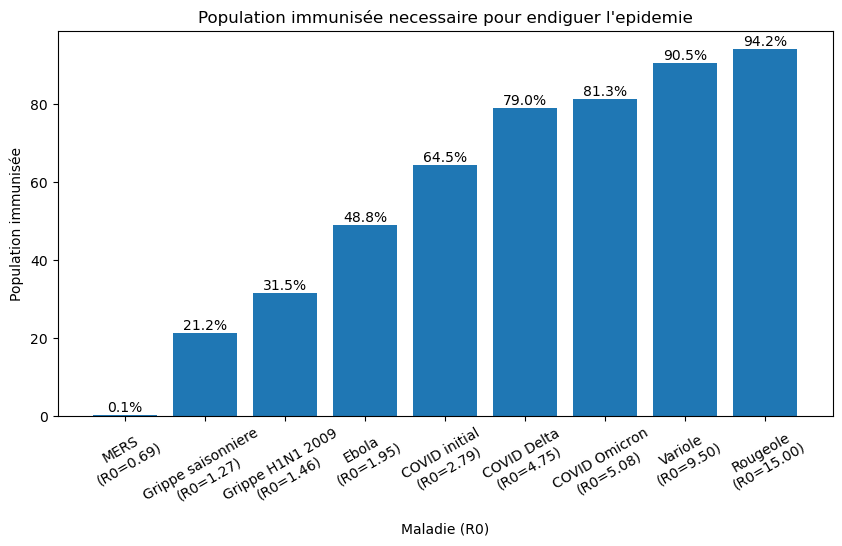

In [12]:
gamma = 0.2
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

virus = [
    "MERS",
    "Grippe saisonniere",
    "Grippe H1N1 2009",
    "Ebola",
    "COVID initial",
    "COVID Delta",
    "COVID Omicron",
    "Variole",
    "Rougeole"
]

R0list = np.array([
    0.69,
    1.27,
    1.46,
    1.95,
    2.79,
    4.75,
    5.08,
    9.5,
    15.0
])

# beta = gamma * R0  (si S_init = 1)
betaTab = gamma * R0list

R0Final = np.empty(betaTab.size)
RFinal = np.empty(betaTab.size)
immunisesFinal = np.empty(betaTab.size)
epidemie_endigue_list = np.empty(betaTab.size)


for k, beta in enumerate(betaTab):
    epidemie_endigue=False
    R0 = beta / gamma * S_init
    R0Final[k] = R0

    S = np.empty(n)
    I = np.empty(n)
    R = np.empty(n)

    y = np.empty(3)
    y[0] = S_init
    y[1] = I_init
    y[2] = R_init

    params = {"beta": beta, "gamma": gamma}
    model = mathUtils.SIR(params)
    deriv = model.deriv_SIR
    euler = model.euler

    for i in range(n):
        S[i] = y[0]
        I[i] = y[1]
        R[i] = y[2]
        t = temps[i]
        y = euler(t, dt, y, deriv)
        Rt= S[i]*R0
        if not epidemie_endigue and Rt<=1  :
            epidemie_endigue = True
            epidemie_endigue_list[k]=(1-S[i])*100

    RFinal[k] = R[-1]
    immunisesFinal[k] = 100 * R[-1]

x = np.arange(len(virus))

labels = [
    f"{virus[i]}\n(R0={R0list[i]:.2f})"
    for i in range(len(virus))
]

plt.figure(figsize=(10, 5))
plt.bar(x, epidemie_endigue_list)

plt.xticks(x, labels, rotation=30)
plt.xlabel("Maladie (R0)")
plt.ylabel("Population immunisée")
plt.title("Population immunisée necessaire pour endiguer l'epidemie")

for i, v in enumerate(epidemie_endigue_list):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.savefig("histogramme_immunités", bbox_inches='tight')
plt.show()

### Pour le covid on retrouve le R=1-1/Rt(0)=67% qu'ils avaient communiqué pendant l'epidemie :
- Avec Rt=S*R0 donc S=1/R0=1/3 pour Rt=1 le seuil. 
- Et donc si I=0 (dans un cas ideal ou on part d'une population immunisé et qu'un seul patient 0) --> R=1-S=1-1/Rt(0)=1-1/3= 67%

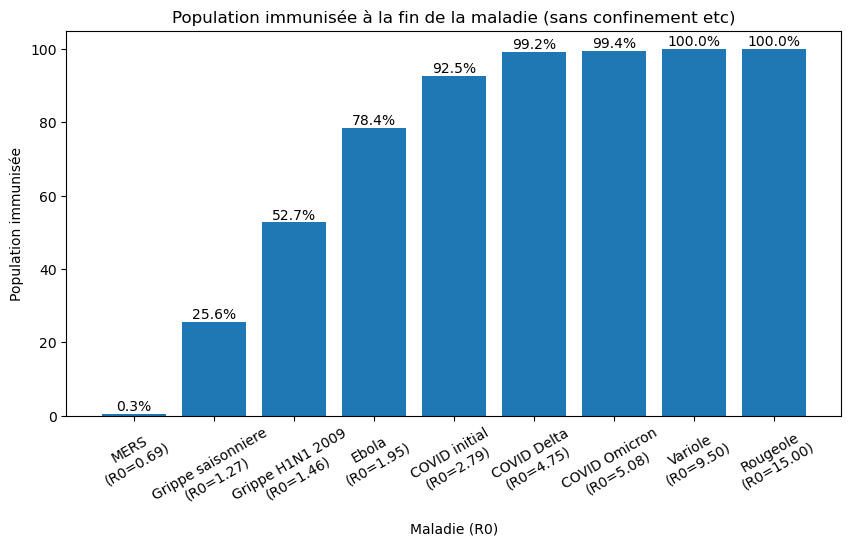

In [13]:

plt.figure(figsize=(10, 5))
plt.bar(x, immunisesFinal)

plt.xticks(x, labels, rotation=30)
plt.xlabel("Maladie (R0)")
plt.ylabel("Population immunisée")
plt.title("Population immunisée à la fin de la maladie (sans confinement etc)")

for i, v in enumerate(immunisesFinal):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.savefig("histogramme_immunités", bbox_inches='tight')
plt.show()